In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [2]:
# Load and prepare the dataset
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.rename(columns={'Date': 'ds', 'Temp': 'y'}, inplace=True)

In [3]:
# Split the data
df_train = df[df['ds'] <= "1990-11-30"]
df_test = df[df['ds'] > "1990-11-30"]

# Prophet requires the dataframe to be sorted
df_train.sort_values('ds', inplace=True)
df_test.sort_values('ds', inplace=True)

/tmp/ipython-input-3412075395.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.sort_values('ds', inplace=True)
/tmp/ipython-input-3412075395.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.sort_values('ds', inplace=True)


In [4]:
# Initialize and fit the Prophet model
model = Prophet(yearly_seasonality=True)
model.fit(df_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmprfc4nosu/0humhuez.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprfc4nosu/su508018.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17646', 'data', 'file=/tmp/tmprfc4nosu/0humhuez.json', 'init=/tmp/tmprfc4nosu/su508018.json', 'output', 'file=/tmp/tmprfc4nosu/prophet_model5pm4bohz/prophet_model-20250815150537.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:05:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:05:38 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [5]:
# Create a DataFrame with future dates
future_dates = model.make_future_dataframe(periods=len(df_test), freq='D')

# Make predictions
forecast = model.predict(future_dates)

In [6]:
# Join the forecast with the actual test data
forecast_df = forecast[['ds', 'yhat']].set_index('ds')
test_df = df_test.set_index('ds')
evaluation_df = test_df.join(forecast_df)

# Calculate performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from numpy import sqrt

mae = mean_absolute_error(evaluation_df['y'], evaluation_df['yhat'])
rmse = sqrt(mean_squared_error(evaluation_df['y'], evaluation_df['yhat']))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")



MAE: 1.85
RMSE: 2.55


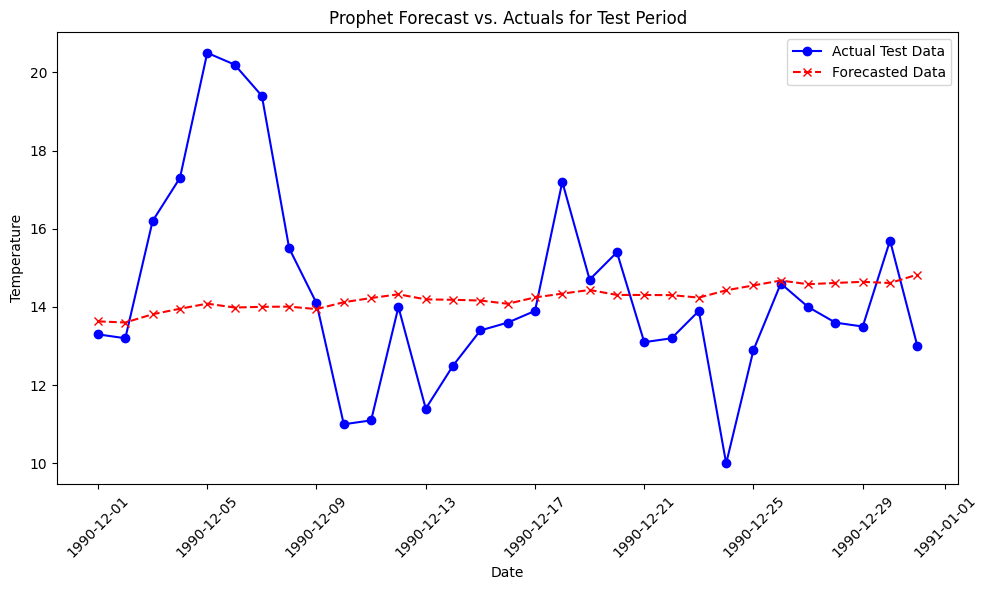

In [7]:
# 5. Filter the forecast to only include the test period
forecast_test = forecast.set_index('ds').loc[df_test['ds']]

# 6. Plot the test data and the forecast
plt.figure(figsize=(10, 6))

# Plot the actual values from the test data
plt.plot(df_test['ds'], df_test['y'], 'o-', label='Actual Test Data', color='blue')

# Plot the forecasted values for the test period
plt.plot(df_test['ds'], forecast_test['yhat'], 'x--', label='Forecasted Data', color='red')

plt.title('Prophet Forecast vs. Actuals for Test Period')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()